# 03 — Model Explainability
### SHAP Analysis of XGBoost Network Intrusion Detector

SHAP (SHapley Additive exPlanations) provides theoretically grounded, additive feature
attributions for every prediction. This notebook interprets the XGBoost model trained
in notebook 02 at both the **global** (dataset-wide) and **local** (per-prediction) level.

| Plot | What it shows |
|---|---|
| Feature importance bar | Mean \|SHAP\| value — overall feature impact |
| Beeswarm summary | Distribution of SHAP values + direction of effect |
| Waterfall (normal) | Why a benign connection was classified as safe |
| Waterfall (attack) | Why a malicious connection was flagged |
| Dependence plot | How the top feature's impact varies with its value |

In [1]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

warnings.filterwarnings("ignore")
shap.initjs()
plt.rcParams.update({"figure.dpi": 100})

## 1. Load Model & Test Data

In [2]:
model = joblib.load("models/xgb_model.joblib")

X_test = pd.read_parquet("data/processed/X_test.parquet")
y_test = pd.read_parquet("data/processed/y_test.parquet").squeeze()

with open("models/feature_meta.json") as f:
    meta = json.load(f)
NUM_FEATURES = meta["NUM_FEATURES"]
CAT_FEATURES = meta["CAT_FEATURES"]

print(f"Test set : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"Attack rate : {y_test.mean():.3f}")

Test set : 100,000 rows × 43 columns
Attack rate : 0.126


## 2. SHAP Explainer Setup

`TreeExplainer` computes exact SHAP values for tree-based models — no approximation needed.

We extract the XGBoost classifier from the sklearn Pipeline, transform the test data using
the fitted preprocessor, and reconstruct post-encoding feature names for interpretable plots.

A 5,000-row subsample is used for SHAP computation; the full test set can be used at the
cost of longer runtime.

In [3]:
preprocessor = model.named_steps["prep"]
xgb_clf = model.named_steps["clf"]

# Reconstruct feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES + cat_feature_names
print(f"Total post-encoding features: {len(feature_names)}")

# Transform test data and wrap in DataFrame so SHAP carries feature names
X_test_arr = preprocessor.transform(X_test)
X_test_transformed = pd.DataFrame(X_test_arr, columns=feature_names)

# Stratified subsample for SHAP
SHAP_SAMPLE = 5_000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test_transformed), SHAP_SAMPLE, replace=False)
X_shap = X_test_transformed.iloc[sample_idx]
y_shap = y_test.iloc[sample_idx].values

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_shap)
print(f"SHAP values computed for {SHAP_SAMPLE:,} samples")

Total post-encoding features: 200
SHAP values computed for 5,000 samples


## 3. Global Feature Importance

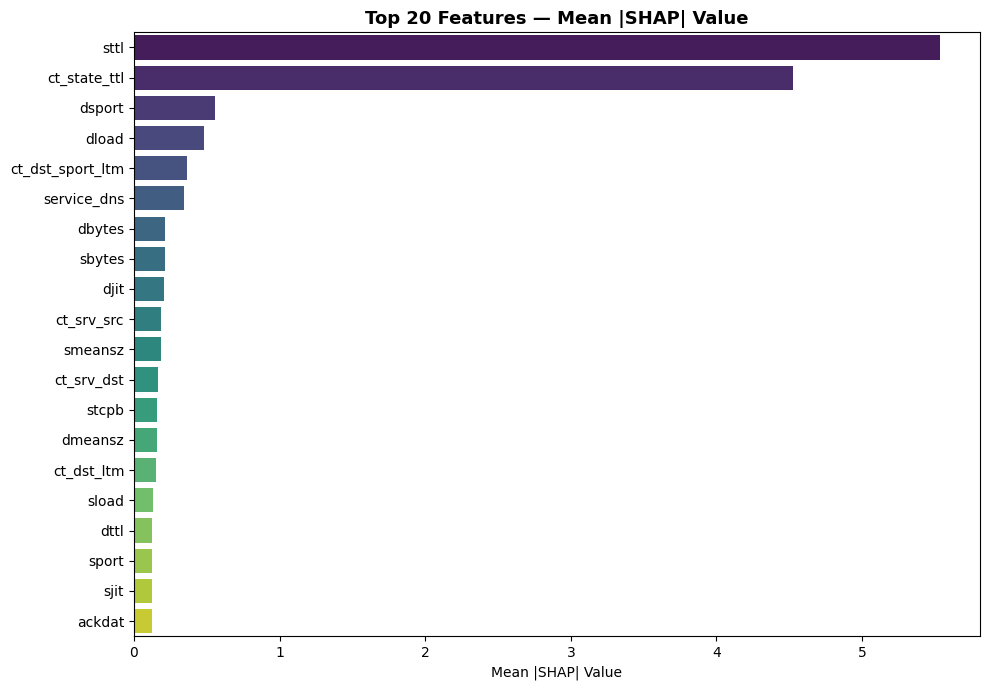


Top 10:
         feature  mean_|SHAP|
            sttl     5.533323
    ct_state_ttl     4.526338
          dsport     0.556370
           dload     0.481693
ct_dst_sport_ltm     0.364391
     service_dns     0.344317
          dbytes     0.212521
          sbytes     0.210965
            djit     0.203934
      ct_srv_src     0.188050


In [4]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": feature_names, "mean_|SHAP|": mean_abs_shap})
    .sort_values("mean_|SHAP|", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="mean_|SHAP|", y="feature", palette="viridis")
plt.title("Top 20 Features — Mean |SHAP| Value", fontsize=13, fontweight="bold")
plt.xlabel("Mean |SHAP| Value")
plt.ylabel("")
plt.tight_layout()
plt.savefig("data/processed/fig_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10:")
print(importance_df.head(10).to_string(index=False))

## 4. SHAP Beeswarm Summary

Each dot is one prediction. **Colour** = feature value (red = high, blue = low).
**Horizontal position** = SHAP value (positive → pushes toward *attack*, negative → *normal*).

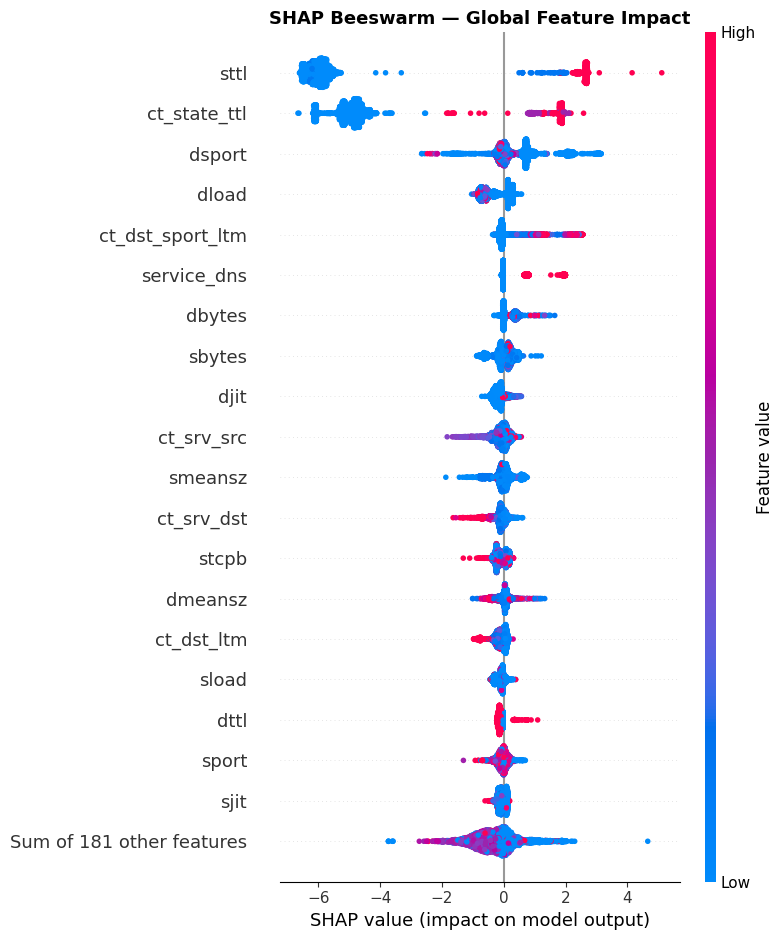

In [5]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm — Global Feature Impact", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/fig_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Waterfall Plots — Individual Predictions

Waterfall plots decompose a single prediction into per-feature contributions,
starting from the model's base rate (E[f(x)]) and ending at the final prediction.

We select one correctly classified **normal** flow and one correctly classified **attack** flow.

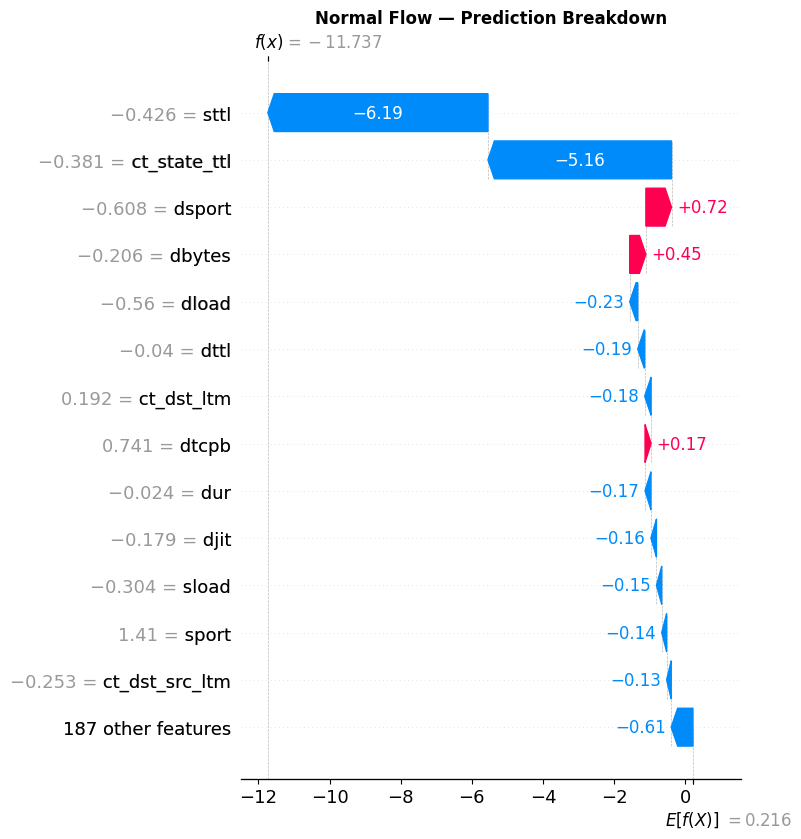

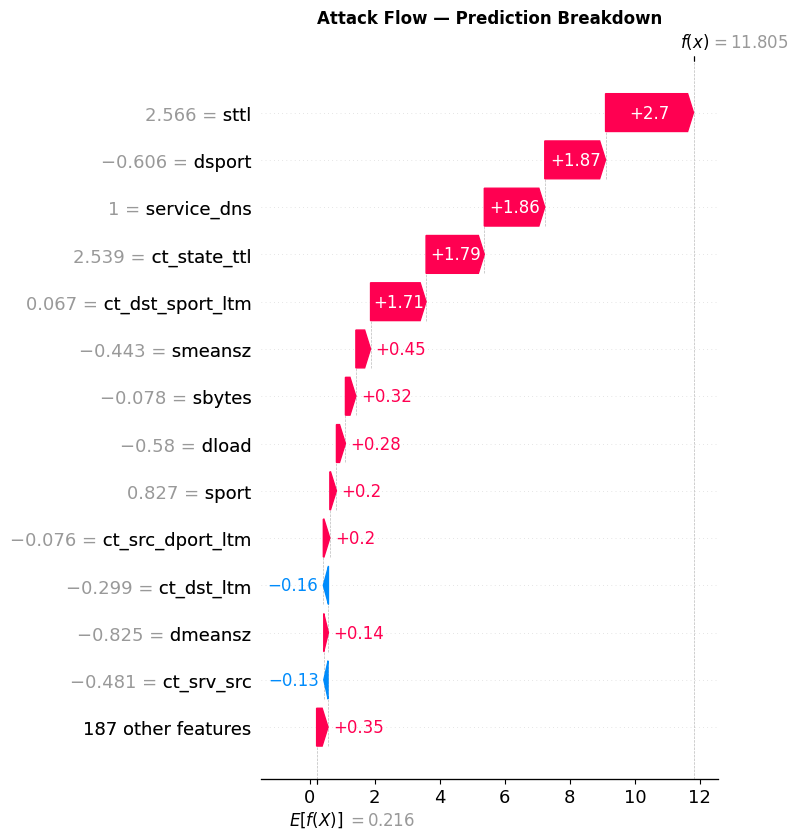

In [6]:
# Determine predicted labels from SHAP values (log-odds space: >0 → attack)
log_odds = shap_values.values.sum(axis=1) + explainer.expected_value
y_pred_shap = (log_odds > 0).astype(int)

correct_normal = np.where((y_shap == 0) & (y_pred_shap == 0))[0]
correct_attack = np.where((y_shap == 1) & (y_pred_shap == 1))[0]

normal_i = correct_normal[0]
attack_i = correct_attack[0]

# Normal flow
shap.plots.waterfall(shap_values[normal_i], max_display=14, show=False)
plt.title("Normal Flow — Prediction Breakdown", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/fig_shap_waterfall_normal.png", dpi=150, bbox_inches="tight")
plt.show()

# Attack flow
shap.plots.waterfall(shap_values[attack_i], max_display=14, show=False)
plt.title("Attack Flow — Prediction Breakdown", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/fig_shap_waterfall_attack.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Dependence Plot — Top Feature

Shows how the top feature's SHAP value varies with its raw value.
Colour encodes the feature SHAP most interacts with (auto-selected).

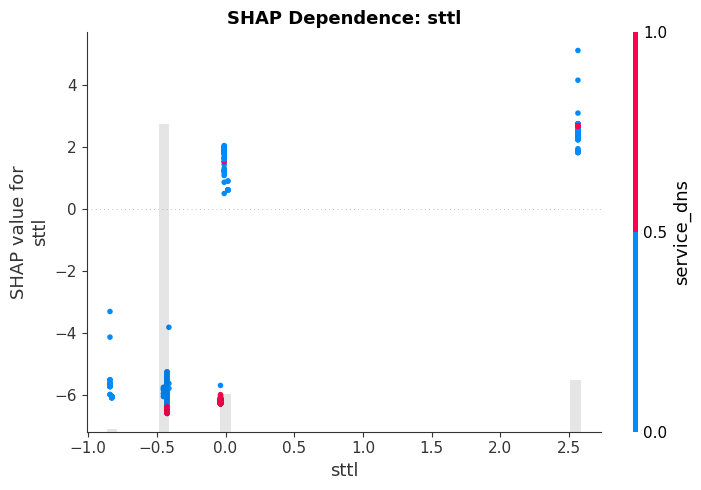

Top feature : sttl
Mean |SHAP| : 5.5333


In [7]:
top_feature = importance_df.iloc[0]["feature"]
top_idx = feature_names.index(top_feature)

shap.plots.scatter(shap_values[:, top_idx], color=shap_values, show=False)
plt.title(f"SHAP Dependence: {top_feature}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/fig_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top feature : {top_feature}")
print(f"Mean |SHAP| : {importance_df.iloc[0]['mean_|SHAP|']:.4f}")